## Overview 
Inspired by the paper by Wan et al on 'Influence of the Discretization Methods on the Distribution of Relaxation Times Deconvolution: Implementing Radial Basis Functions with DRTtools', I wonder if we can resolve the issue of fluctuations in the DRT spectrum as $M$, the number of lifetimes we fit, approaches $N$, the number of time samples we fit to, by using a sinc approximation rather than a Dirac Delta Approximation. 

$$y(t) = y_{\infin} + \int_{0}^{\infin}g(\tau)e^{-t/ \tau}d{\tau}$$

Rather than assuming the form of $g(\tau) = \sum_m^M x_m\delta(\tau-\tau_m)$, we can approximate $g(\tau) = \sum_m x_m\delta(\tau-\tau_m)$

## Comparing a single perfect decay lifetime under DRT to a sinc function

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
import torch 
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

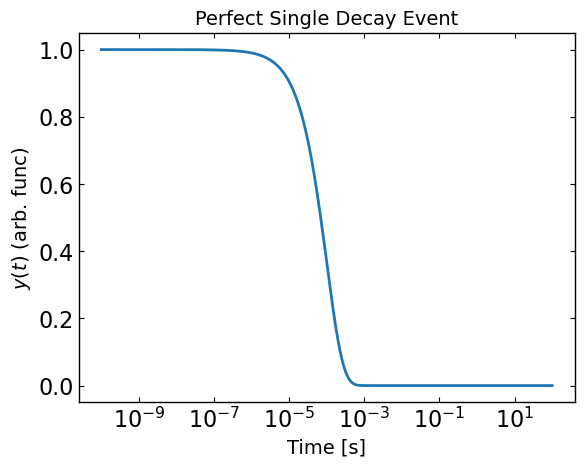

In [2]:
# Create a perfect curve 
y_0 = 1
tau = 1E-4
time = np.geomspace(1E-10, 1E2, 1000)
y_t = y_0 * np.exp(-time/tau)

plt.plot(time, y_t)
plt.title("Perfect Single Decay Event")
plt.xlabel("Time [s]")
plt.xscale('log')
plt.ylabel("$y(t)$ (arb. func)")
plt.show()

In [3]:
# Calculate the limits of tau based off the observation window
tau_min = 1/np.pi * (time[1] - time[0])
tau_max = 1/(2*np.pi) * (time[-1]- time[0])
tau_grid = np.geomspace(tau_min, tau_max, 2000)

In [4]:
tau_min

np.float64(8.926915480675671e-13)

In [5]:
# Find the drt transform of this event and plot 
drt_fit = drt.alpha_linear_fit(time, y_t, time)

In [6]:
# Define a sinc function 
def sinc(time, tau, a, b):
    return b*(1/(a))*np.sinc(np.log(time/tau)/a)

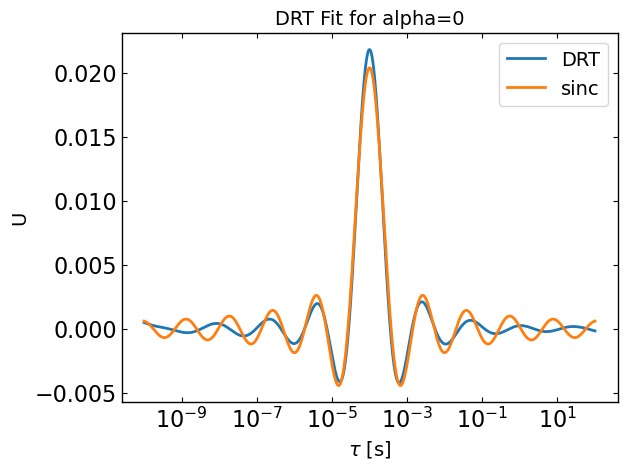

In [7]:
# Plot the resulting DRT curve against a sinc function
plt.plot(time, drt_fit.U, label='DRT')

a = 1.325
plt.plot(time, sinc(time, tau, a, 0.027), label='sinc')


plt.xlabel('$\\tau$ [s]')
plt.ylabel("U")
plt.xscale('log')
plt.title("DRT Fit for alpha=0")
plt.legend()
plt.show()

In [8]:
# Try actually fitting a sinc curve here 
from scipy.optimize import curve_fit

sinc_tau = lambda time, a, b: sinc(time, tau, a, b)

fit_params, cov = curve_fit(sinc, time, drt_fit.U, p0=[1E-4, 1.36, 0.029])

In [9]:
fit_params

array([9.97873661e-05, 1.32563069e+00, 2.73222454e-02])

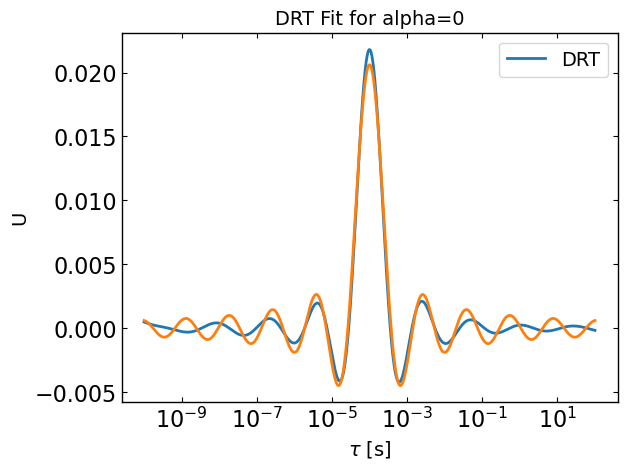

In [10]:
plt.plot(time, drt_fit.U, label='DRT')
plt.plot(time, sinc(time, *fit_params))

plt.xlabel('$\\tau$ [s]')
plt.ylabel("U")
plt.xscale('log')
plt.title("DRT Fit for alpha=0")
plt.legend()
plt.show()

In [11]:
# Test to see if there is a link between the time spacing, tau spacing, or total interval and the parameter a
t_max = 1E2
t_min = 1E-10

delta_t_min = []
a_values = []
b_values = []
error = []

for i in range(1, 10):
    # Calculate the number of decades and points per decade for the time plot
    no_decades = int(np.log10(t_max/t_min))
    ppd = i * 10

    # Generate a time array and calculate the ideal y curve
    time = np.geomspace(t_min, t_max, no_decades*ppd)
    y_t = y_0 * np.exp(-time/tau)

    # Get the DRT for the curve
    drt_fit = drt.alpha_linear_fit(time, y_t, time)

    # Fit params
    fit_params, cov = curve_fit(sinc_tau, time, drt_fit.U, p0=[1.36, 0.029])

    # Get the error between DRT and the fitted params
    error = np.mean((drt_fit.U - sinc_tau(time, *fit_params))**2)

    # Append everything 

We can see that fiting tau values to these oscillations could provide a useful basis. Let's try adapting the linear fit code to work with sinc funcs